### Astrometric Quality Cuts and Cleaning

Gaia encounters issues with astrometry when it cannot reliably calculate a star's motion and position. This is often caused by the object not being a simple, isolated point source. Examples of this would be a binary star system giving unreliable luminosity measurements, or a crowded area of stars interfering with each others light signatures. 

I implemented the following cuts based on the methods mentioned in *Babusiaux et al. (2018)*
(Note that I simplified some models and used approximations of their complicated models/parameters):

1.  **Parallax Precision (`parallax_over_error > 10`)**
    *    Faint or distant stars often have low signal-to-noise ratios. If the uncertainty in parallax is large relative to the parallax itself, the distance estimate ($d \approx 1/\varpi$) becomes meaningless. Due to this I added a filter that ensures the parallax measurement is 10 times larger than its uncertainty (10% precision). This prevents stars from scattering wildly when plotting their absolute magnitudes.

2.  **Renormalized Unit Weight Error (`ruwe < 1.4`)**
    *   Since the standard Gaia pipeline tries to fit every source to a single star, unresolved binaries generate poor fits. To account for this I added a filter for a measurements RUWE score. I referenced a preprint by [Logan Pearce, 2022](http://www.loganpearcescience.com/research/RUWE_as_an_indicator_of_multiplicity.pdf) in order to learn more about how the metric works. I learned the RUWE score measures the "goodness of fit" for an astrometric solution. A score significantly above 1.0 (specifically $>1.4$) indicates the object is likely a binary or a non-stellar object. As a result I excluded all measurements with an RUWE >1.4.

3.  **Photometric Excess Factor (`phot_bp_rp_excess_factor`)**
     *   Gaia measures light in the green, blue and red bands. In crowded fields light from a nearby background star can bleed into the Blue or Red photometers. This effect creates a phantom flux giving the affected star inconsistent colors. As a result, I applied a cut to remove stars where the sum of blue and red flux ($F_{BP} + F_{RP}$) is suspiciously higher than the total green flux ($F_G$). This removes contaminated sources that would otherwise appear as outliers in color space.

In [1]:
import astroquery
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astroquery.gaia import Gaia

In [2]:
Gaia.MAIN_GAIA_TABLE = "gaiadr3.gaia_source" #remove table size warnings

In [3]:
#Function to clean data (method adapted from Babusiaux 2018, changed to work w/ 3rd iteration of Gaia Data)
def clean_gaia_data(data_table):
    # boolean array (mask) that starts as all True
    mask = np.ones(len(data_table), dtype=bool)
    mask &= (data_table['parallax_over_error'] > 10) #This filter removes all data that has a parallax uncertainy > 10%
    # In Data Release 3, these are combined into the RUWE score. An optimal RUWE is 1.0 however Bommert 2020 says anything <1.4 is acceptable
    mask &= (data_table['ruwe'] < 1.4)
    #Next I removed stars where the brightness does not match the opbserved temp (happens w. binaries/overcrowded stars, etc.)
    #Babusiaux does this with a curve defined as Equation 1
    # removing outliers in 'phot_bp_rp_excess_factor' (found outside of 1.0-1.3 range) is effectively the same
    bp_rp = data_table['bp_rp']
    excess_factor = data_table['phot_bp_rp_excess_factor']
    #I created a simplified version of the curve from teh paper
    # 1.0 + 0.015*color^2  <  Factor  <  1.3 + 0.06*color^2
    lower_bound = 1.0 + 0.015 * bp_rp**2
    upper_bound = 1.3 + 0.06 * bp_rp**2
   
    mask &= (excess_factor > lower_bound) & (excess_factor < upper_bound)
    
    # Applying the mask
    cleaned_data = data_table[mask]
    
    print(f"Original rows: {len(data_table)}")
    print(f"Cleaned rows:  {len(cleaned_data)}")
    return cleaned_data

In [4]:
#querying esa gaia database
query = """
SELECT TOP 2000 
source_id, ra, dec, parallax, pmra, pmdec, 
phot_g_mean_mag, bp_rp, 
parallax_over_error, ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 66.75, 15.87, 5))
AND parallax > 10  
"""
# Hyades is only ~45pc away, so parallax must be pretty large
job = Gaia.launch_job_async(query)
hyades_raw = job.get_results()
hyades_clean = clean_gaia_data(hyades_raw)

INFO: Query finished. [astroquery.utils.tap.core]
Original rows: 953
Cleaned rows:  657


In [5]:
# Iterative Algorithm that utilizes sigma-clipping in Proper Motion and Parallax space.

def iterative_cluster_selection(data, sigma=3.0, max_iters=10):

    # boolean mask to track which stars are 'members'
    mask = np.ones(len(data), dtype=bool)
    
    # loop to refine selection
    for i in range(max_iters):
        # Selects the current working set of stars
        current_members = data[mask]
        
        # Calculates the center (median) and spread (std) of this set
        med_pmra = np.median(current_members['pmra'])
        std_pmra = np.std(current_members['pmra'])
        
        med_pmdec = np.median(current_members['pmdec'])
        std_pmdec = np.std(current_members['pmdec'])
        
        med_plx = np.median(current_members['parallax'])
        std_plx = np.std(current_members['parallax'])
        
        # new mask for the next iteration
        # A star is a member if it is within 'sigma' standard deviations of the center in ALL three coordinates.
        new_mask = (
            (np.abs(data['pmra'] - med_pmra) < sigma * std_pmra) &
            (np.abs(data['pmdec'] - med_pmdec) < sigma * std_pmdec) &
            (np.abs(data['parallax'] - med_plx) < sigma * std_plx)
        )
        
        # Once the mask no longer changes stop
        n_old = np.sum(mask)
        n_new = np.sum(new_mask)
        print(f"Iteration {i+1}: Kept {n_new} stars (was {n_old})")
        
        if np.array_equal(mask, new_mask):
            print("Converged!")
            break
            
        # Update the mask for the next loop
        mask = new_mask
        
    return data[mask]

hyades_members = iterative_cluster_selection(hyades_clean, sigma=2.2) 
#I played around with sigmas from 2.0 to 3.0
#Lower sigmas seemed to cut some stars that were still in the cluster, however they removed a high fraction of field stars as well.
# Sigmas >2.5 left far too many field stars to generate accurate plots

Iteration 1: Kept 608 stars (was 657)
Iteration 2: Kept 538 stars (was 608)
Iteration 3: Kept 486 stars (was 538)
Iteration 4: Kept 455 stars (was 486)
Iteration 5: Kept 429 stars (was 455)
Iteration 6: Kept 402 stars (was 429)
Iteration 7: Kept 381 stars (was 402)
Iteration 8: Kept 364 stars (was 381)
Iteration 9: Kept 343 stars (was 364)
Iteration 10: Kept 322 stars (was 343)


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:870: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


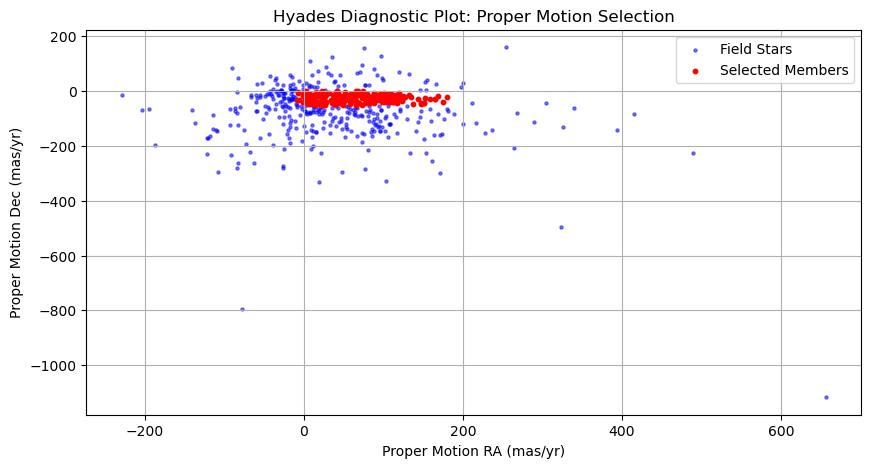

In [6]:
plt.figure(figsize=(10, 5))

# Plot all stars (Background)
plt.scatter(hyades_clean['pmra'], hyades_clean['pmdec'], 
            s=5, color='blue', alpha=0.5, label='Field Stars')

# Plot selected members (Cluster)
plt.scatter(hyades_members['pmra'], hyades_members['pmdec'], 
            s=10, color='red', label='Selected Members')

plt.xlabel('Proper Motion RA (mas/yr)')
plt.ylabel('Proper Motion Dec (mas/yr)')
plt.title('Hyades Diagnostic Plot: Proper Motion Selection')
plt.legend()
plt.grid(True)
plt.show()

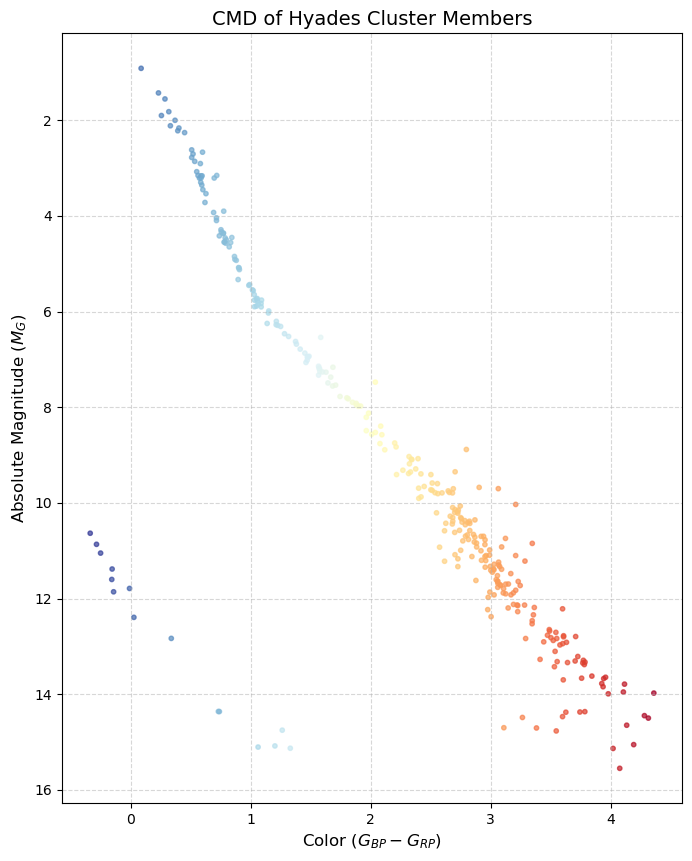

In [7]:
# to find the distance -> Parallax is in mas, so d = 1000 / parallax
distance_pc = 1000.0 / hyades_members['parallax']

# Absolute Magnitude -> M = m - 5 * log10(d) + 5
abs_mag_g = hyades_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5

# Gaia provides 'bp_rp' directly -> (Blue_mag - Red_mag)
color = hyades_members['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Hyades Cluster Members', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

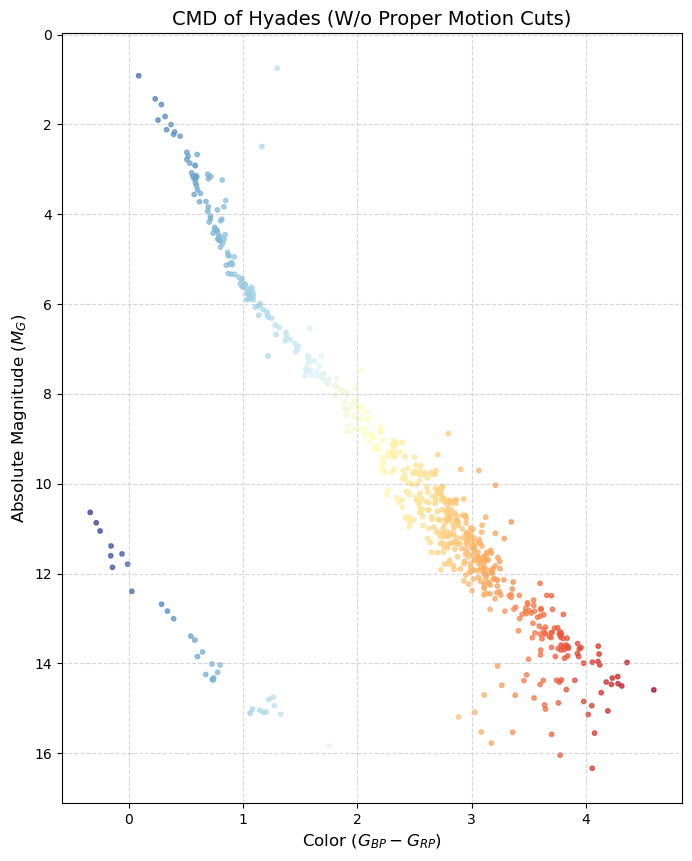

In [8]:
distance_pc = 1000.0 / hyades_clean['parallax']
abs_mag_g = hyades_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = hyades_clean['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Hyades (W/o Proper Motion Cuts)', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

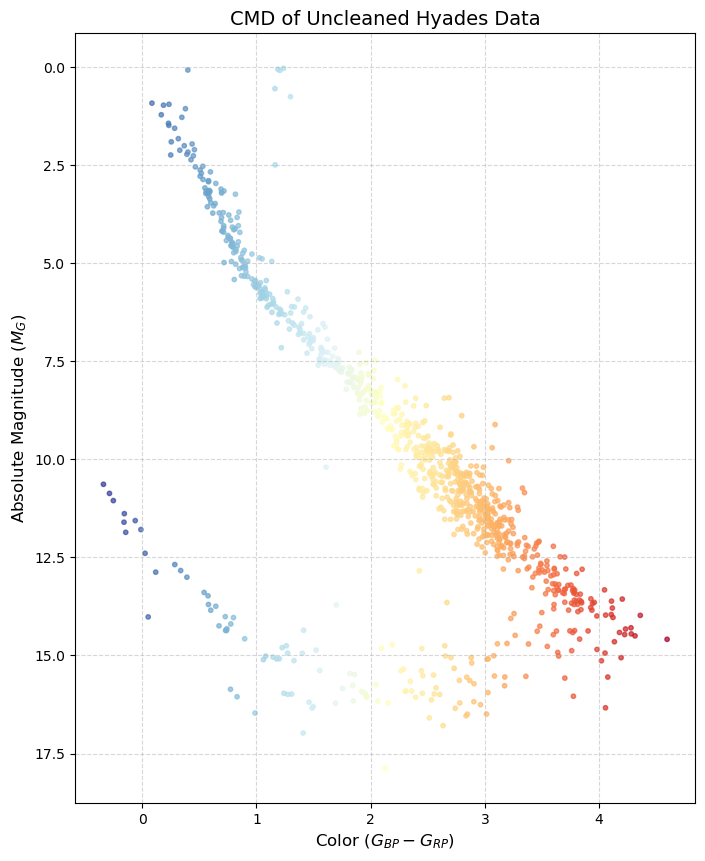

In [9]:
distance_pc = 1000.0 / hyades_raw['parallax']
abs_mag_g = hyades_raw['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = hyades_raw['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Uncleaned Hyades Data', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [10]:
# M67 Query
# Center: RA 132.83, Dec 11.82
# Radius: 1.0 degree b/c the cluster is more compact than Hyaedes
query_m67 = """
SELECT TOP 5000 
source_id, ra, dec, parallax, pmra, pmdec, 
phot_g_mean_mag, bp_rp, 
parallax_over_error, ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 132.83, 11.82, 1.0))
AND parallax > 0.5  -- RELAXED CONSTRAINT: M67 is distant (~1.1 mas)
"""

job_m67 = Gaia.launch_job_async(query_m67)
m67_raw = job_m67.get_results()
m67_clean = clean_gaia_data(m67_raw)

INFO: Query finished. [astroquery.utils.tap.core]
Original rows: 5000
Cleaned rows:  1731


In [11]:
m67_members = iterative_cluster_selection(m67_clean, sigma=1.97)

print(f"Median Parallax: {np.median(m67_members['parallax']):.2f} mas")

#I found that a sigma of 1.95 left only a very concentrated mass of stars
#I am assuming this is the M67 cluster
#Funnily enough, any sigma > 2.0 captured an extraordinary amount of field stars
#Like that specific value was some sort of saddle point? Quite intriguing

Iteration 1: Kept 1593 stars (was 1731)
Iteration 2: Kept 1322 stars (was 1593)
Iteration 3: Kept 1072 stars (was 1322)
Iteration 4: Kept 852 stars (was 1072)
Iteration 5: Kept 612 stars (was 852)
Iteration 6: Kept 466 stars (was 612)
Iteration 7: Kept 408 stars (was 466)
Iteration 8: Kept 360 stars (was 408)
Iteration 9: Kept 302 stars (was 360)
Iteration 10: Kept 262 stars (was 302)
Median Parallax: 1.15 mas


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:870: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


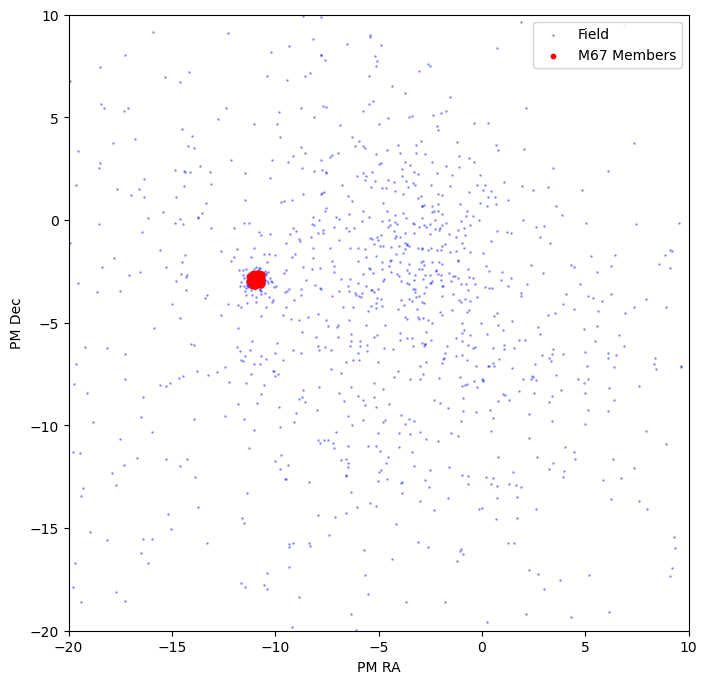

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(m67_clean['pmra'], m67_clean['pmdec'], s=1, color='blue', alpha=0.3, label='Field')
plt.scatter(m67_members['pmra'], m67_members['pmdec'], s=10, color='red', label='M67 Members')
plt.xlim(-20, 10) # Zoom in! M67 motion is small.
plt.ylim(-20, 10)
plt.xlabel('PM RA')
plt.ylabel('PM Dec')
plt.legend()
plt.show()

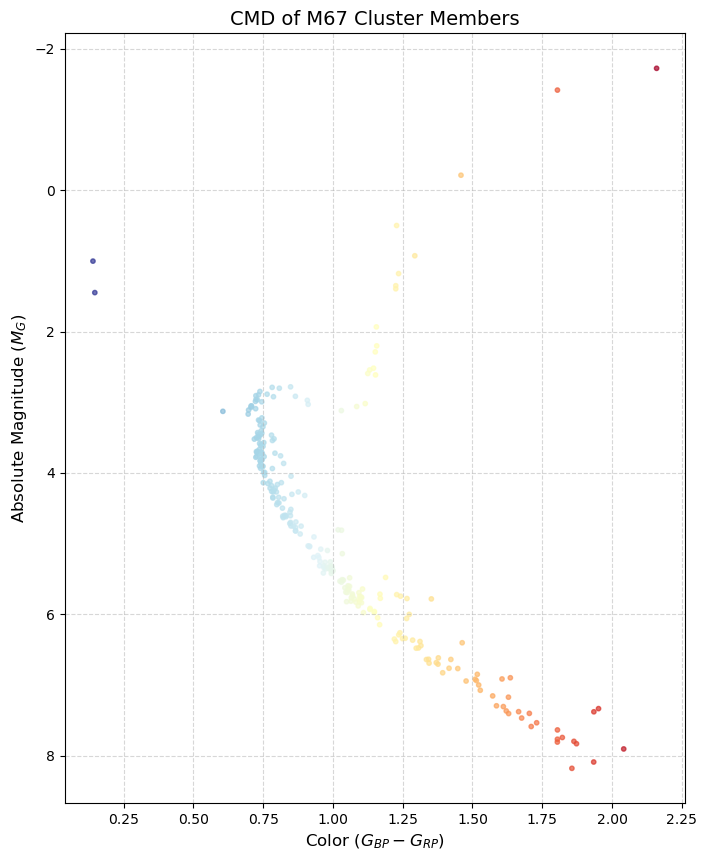

In [13]:
distance_pc = 1000.0 / m67_members['parallax']
abs_mag_g = m67_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = m67_members['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)
plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of M67 Cluster Members', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

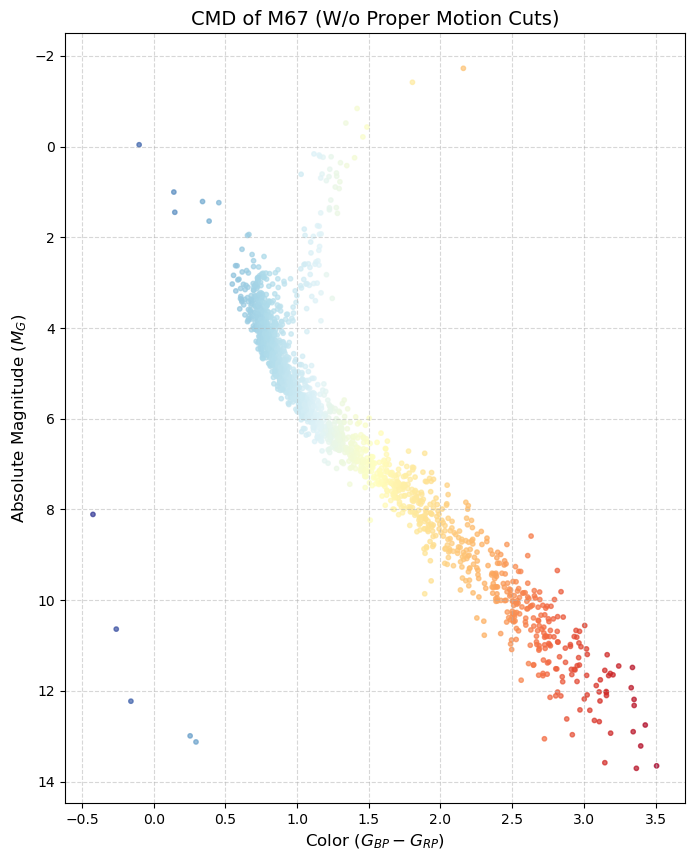

In [14]:

distance_pc = 1000.0 / m67_clean['parallax']


abs_mag_g = m67_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5


color = m67_clean['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of M67 (W/o Proper Motion Cuts)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

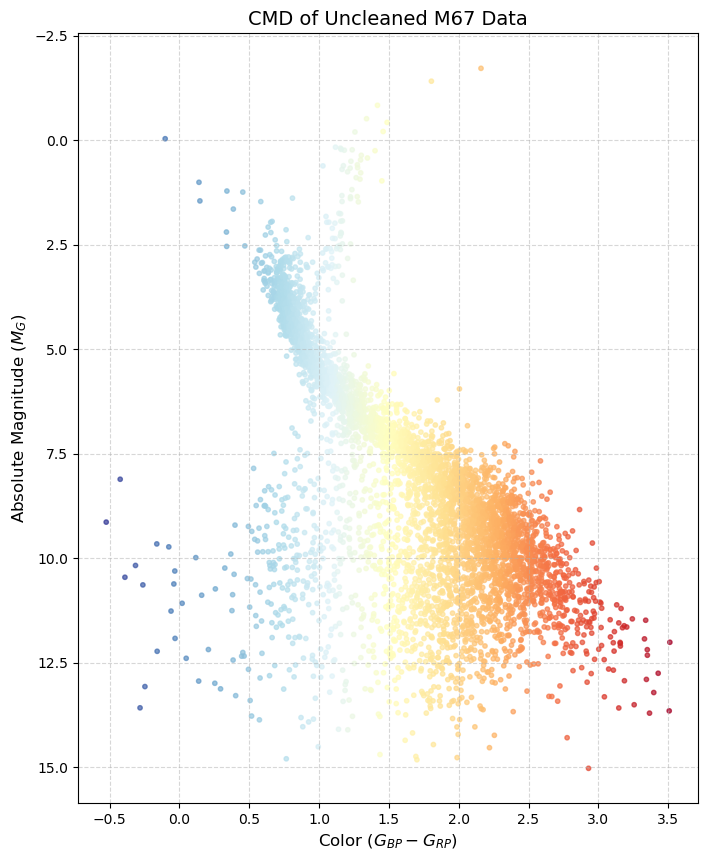

In [15]:

distance_pc = 1000.0 / m67_raw['parallax']


abs_mag_g = m67_raw['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5


color = m67_raw['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Uncleaned M67 Data', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [16]:
print("Fetching NGC 6397 data...")
# Coordinates: RA ~ 265.17, Dec ~ -53.67
# Parallax is small (~0.4 mas), so I lowered the strict lower bound to 0.25
#I also queried way more stars since NGC is a MASSIVE cluster
query_ngc = """
SELECT TOP 50000 
source_id, ra, dec, parallax, pmra, pmdec, 
phot_g_mean_mag, bp_rp, 
parallax_over_error, ruwe, phot_bp_rp_excess_factor
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 265.175, -53.674, 0.5))
AND parallax > 0.25
"""

job_ngc = Gaia.launch_job_async(query_ngc)
ngc_raw = job_ngc.get_results()

ngc_clean = clean_gaia_data(ngc_raw)

Fetching NGC 6397 data...
INFO: Query finished. [astroquery.utils.tap.core]
Original rows: 50000
Cleaned rows:  3302


### Locating NGC 6397

   My algorithm was running into issues when it came to isolating NGC 6397. I could clearly see the cluster on my plot, however my function seemed to select every field star, and remove the cluster! I tried to fix this by updating my algorithm. 
   
   First I added two parameters that set a starting point to begin sigma clipping (Evan from class gave me this idea, shoutout Evan!). Before this, the function was just starting at (0, 0) in proper motion space. This didn't work though! I actually used Gemini to help me trouble shoot and find out why adjusting the starting point wasn't working. It pointed out that my standard deviation of 2-3 sigmas was so large that it was capturing field stars. Once it captured the field stars the next iteration of the cuts would pull the center back to middle of the field!! So after learning this, I tried using a much smaller sigma, but that ran into the same issue, and then just eliminated all the field stars as well, giving me no selected stars.

   I realized that I had to fix this by eliminating the field stars from the search before starting the sigma clipping. This method seemed plausible for this cluster since the area where the stars were concentrated was so clear cut in my PM graph.

   I eliminated the field stars by creating a mask around the visible cluster. I essentially defined the coordinates of the cluster using the [coordinates provided by CalTech and Euclid](https://euclid.caltech.edu/image/euclid20231107d-euclid-s-view-of-globular-cluster-ngc-6397#:~:text=Astrometrics.%20Position%20()%20RA%20=%2017h%2040m,Orientation%20North%20is%202.2%C2%B0%20left%20of%20vertical). I allowed for +/- 5 mas/yr as the bounds of the mask. After this, I only allowed my sigma clipping algorithm to iterate through the stars within the mask!

In [17]:
def iterative_cluster_selection_ngc(data, sigma=3.0, max_iters=10, 
                                pm_center_guess=None, plx_center_guess=None):

    mask = np.ones(len(data), dtype=bool)
    
    for i in range(max_iters):
        current = data[mask]
        
        # Safety check
        if len(current) < 2:
            print("Lost all stars! Try lowering sigma or better guesses.")
            return data[mask]

        # determine Center
        if i == 0 and pm_center_guess is not None:
            # FORCE the first center to be your manual guess
            med_pmra, med_pmdec = pm_center_guess
            med_plx = plx_center_guess if plx_center_guess else np.median(current['parallax'])
        else:
            # now let the data decide
            med_pmra = np.median(current['pmra'])
            med_pmdec = np.median(current['pmdec'])
            med_plx = np.median(current['parallax'])
            
        # Calculate std
        std_pmra = np.std(current['pmra'])
        std_pmdec = np.std(current['pmdec'])
        std_plx = np.std(current['parallax'])
        
        # Applying the cut
        # A star is a member if it is within 'sigma' std devs of the CENTER
        new_mask = (
            (np.abs(data['pmra'] - med_pmra) < sigma * std_pmra) &
            (np.abs(data['pmdec'] - med_pmdec) < sigma * std_pmdec) &
            (np.abs(data['parallax'] - med_plx) < sigma * std_plx)
        )
        
        print(f"Iter {i}: Center=({med_pmra:.2f}, {med_pmdec:.2f}), Kept {np.sum(new_mask)}")
        
        if np.array_equal(mask, new_mask):
            print("Converged!")
            break
            
        mask = new_mask
        
    return data[mask]

Original stars: 3302
Stars in the 'box': 585
Iter 0: Center=(3.30, -17.60), Kept 496
Iter 1: Center=(3.23, -17.61), Kept 466
Iter 2: Center=(3.25, -17.63), Kept 440
Iter 3: Center=(3.26, -17.63), Kept 429
Iter 4: Center=(3.27, -17.63), Kept 423
Iter 5: Center=(3.27, -17.63), Kept 421
Iter 6: Center=(3.27, -17.62), Kept 421
Converged!


/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:870: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


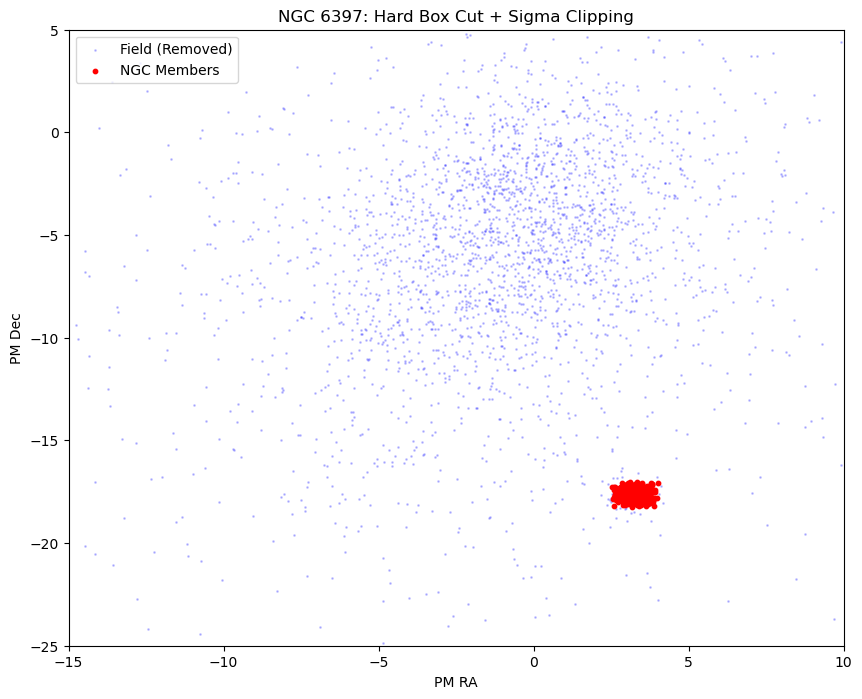

In [18]:
# creating the dimensions of my mask
ra_guess = 3.3
dec_guess = -17.6
box_width = 5.0  # A +/- 5 mas/yr window seemed reasonable for a tight globular cluster

# Create a mask that only keeps stars inside this small box
pre_filter_mask = (
    (ngc_clean['pmra'] > ra_guess - box_width) & 
    (ngc_clean['pmra'] < ra_guess + box_width) & 
    (ngc_clean['pmdec'] > dec_guess - box_width) & 
    (ngc_clean['pmdec'] < dec_guess + box_width)
)

# apply cut immediately to get a smaller, cleaner dataset
ngc_focused = ngc_clean[pre_filter_mask]

print(f"Original stars: {len(ngc_clean)}")
print(f"Stars in the 'box': {len(ngc_focused)}")


# after creating the mask I ran the iterative algorithm on 'ngc_focused'.
# Since the field stars are gone, the stats will be calculated purely from the cluster!

ngc_members = iterative_cluster_selection_ngc(
    ngc_focused, 
    sigma=2.5,  #small sigma since its a really concentrated area
    pm_center_guess=(ra_guess, dec_guess)
)

#plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plottin the original dataset in blue
plt.scatter(ngc_clean['pmra'], ngc_clean['pmdec'], s=1, color='blue', alpha=0.2, label='Field (Removed)')

# Plotting the selected members in red
plt.scatter(ngc_members['pmra'], ngc_members['pmdec'], s=10, color='red', label='NGC Members')

plt.xlim(-15, 10)
plt.ylim(-25, 5)
plt.xlabel('PM RA')
plt.ylabel('PM Dec')
plt.title('NGC 6397: Hard Box Cut + Sigma Clipping')
plt.legend()
plt.show()

### LOOK AT THAT BEAUTIFUL GRAPH!!!! WOOHOO!

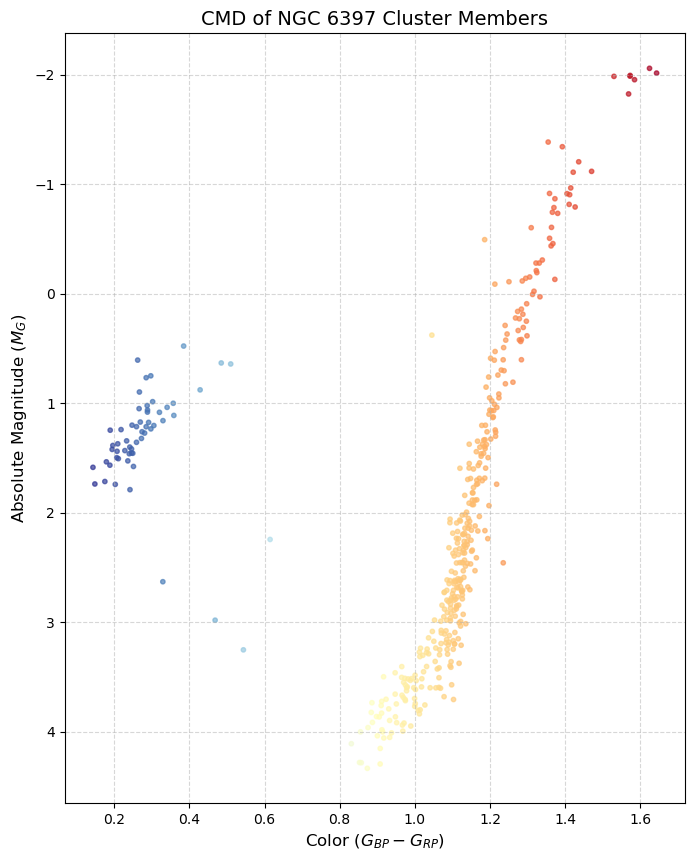

In [19]:

distance_pc = 1000.0 / ngc_members['parallax']


abs_mag_g = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5


color = ngc_members['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of NGC 6397 Cluster Members', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

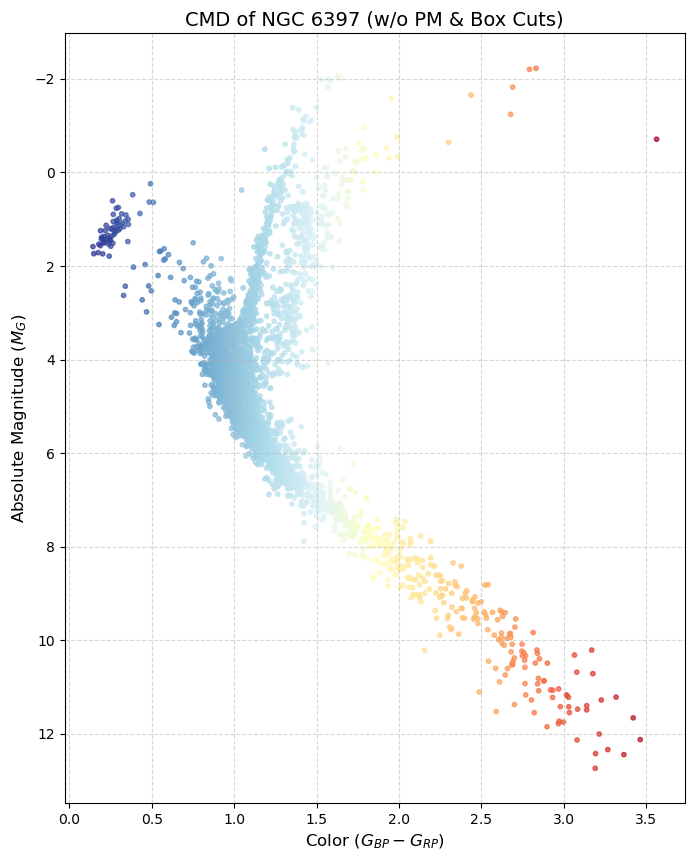

In [20]:
distance_pc = 1000.0 / ngc_clean['parallax']
abs_mag_g = ngc_clean['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = ngc_clean['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of NGC 6397 (w/o PM & Box Cuts)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

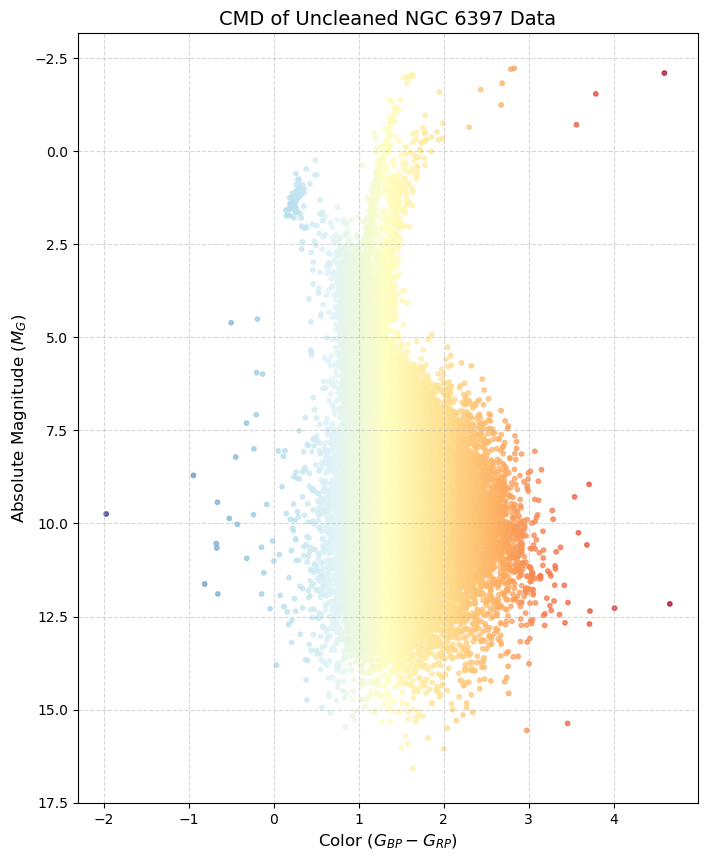

In [21]:

distance_pc = 1000.0 / ngc_raw['parallax']


abs_mag_g = ngc_raw['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5


color = ngc_raw['bp_rp']

#plot
plt.figure(figsize=(8, 10))
plt.scatter(color, abs_mag_g, s=10, c=color, cmap='RdYlBu_r', alpha=0.7)

plt.gca().invert_yaxis()

plt.xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
plt.ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
plt.title('CMD of Uncleaned NGC 6397 Data', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [22]:
import pandas as pd
def read_mist_isochrones(filename):
    """
    Reads a MIST .cmd file and returns a dictionary of isochrones.
    Structure: isochrones[feh][log_age] = table_of_data
    """
    isochrones = {}
    
    # open file
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # find the column names 
    col_names = []
    data_start = 0
    
    for i, line in enumerate(lines):
        if line.startswith('#'):
            if not lines[i+1].startswith('#'):
                col_names = line.strip().lstrip('#').split()
                data_start = i + 1
                break
    
    print(f"Detected {len(col_names)} columns: {col_names[:5]} ...")
    
    # Load the data
        # Read file
    df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)
        
        # Group by Metallicity and Age
    age_col = [c for c in df.columns if 'age' in c and 'yr' in c][0]
    feh_col = [c for c in df.columns if 'Fe/H' in c][0]
        
        # dict structure
    unique_feh = df[feh_col].unique()
    for feh in unique_feh:
        isochrones[feh] = {}
        feh_group = df[df[feh_col] == feh]
        unique_ages = feh_group[age_col].unique()
            
        for age in unique_ages:
            isochrones[feh][age] = feh_group[feh_group[age_col] == age]
                

    print(f"Loaded isochrones for [Fe/H]: {list(isochrones.keys())}")
    return isochrones

In [23]:
iso_metallicity_pt25 = read_mist_isochrones("MIST_iso_697978eddda80.iso.cmd")

Detected 34 columns: ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff'] ...


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_80274/816671463.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)


Loaded isochrones for [Fe/H]: [np.float64(0.25)]


In [24]:
iso_metallicity_0 = read_mist_isochrones("MIST_iso_697978730525e.iso.cmd")

Detected 34 columns: ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff'] ...


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_80274/816671463.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)


Loaded isochrones for [Fe/H]: [np.float64(0.0)]


In [25]:
iso_metallicity_neg_pt25 = read_mist_isochrones("MIST_iso_698529b3dfa59.iso.cmd")

Detected 34 columns: ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff'] ...


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_80274/816671463.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)


Loaded isochrones for [Fe/H]: [np.float64(-0.25)]


In [26]:
iso_metallicity_neg_pt5 = read_mist_isochrones("MIST_iso_697977f1c7c12.iso.cmd")

Detected 34 columns: ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff'] ...


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_80274/816671463.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)


Loaded isochrones for [Fe/H]: [np.float64(-0.5)]


In [27]:
iso_metallicity_neg_2 = read_mist_isochrones("MIST_iso_697977734f71f.iso.cmd")

Detected 34 columns: ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'log_Teff'] ...


/var/folders/fb/v0r0g16x0tz2ph5r5ybzfhn40000gn/T/ipykernel_80274/816671463.py:28: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, delim_whitespace=True, comment='#', names=col_names)


Loaded isochrones for [Fe/H]: [np.float64(-2.0)]


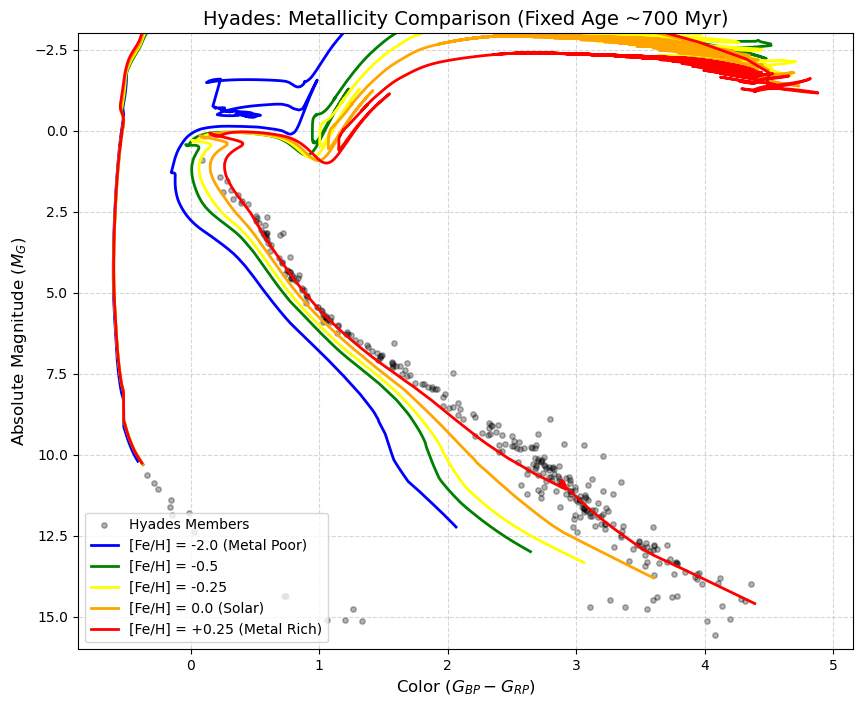

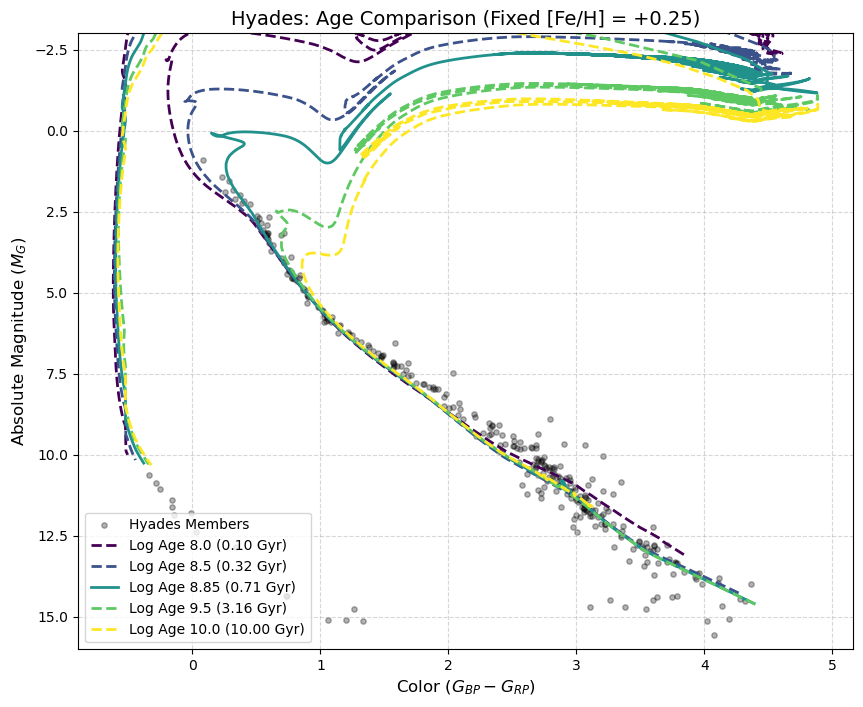

In [28]:
#prepping data
distance_pc = 1000.0 / hyades_members['parallax']
abs_mag_g = hyades_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = hyades_members['bp_rp']

def plot_single_iso(ax, iso_dict, log_age, color_code, label_text, linestyle='-'):
    
    feh_key = list(iso_dict.keys())[0] # Get the metallicity float key 
    
    # Find closest available age in this file
    avail_ages = np.array(list(iso_dict[feh_key].keys()))
    closest_age = avail_ages[np.abs(avail_ages - log_age).argmin()]
    
    data = iso_dict[feh_key][closest_age]
    
    # Try common column names
    try:
        G = data['Gaia_G_EDR3']
        BP = data['Gaia_BP_EDR3']
        RP = data['Gaia_RP_EDR3']
    except KeyError:
        # Fallback if names differ
        cols = data.columns
        G = data[[c for c in cols if 'Gaia_G' in c][0]]
        BP = data[[c for c in cols if 'Gaia_BP' in c][0]]
        RP = data[[c for c in cols if 'Gaia_RP' in c][0]]
        
    ax.plot(BP-RP, G, color=color_code, label=label_text, lw=2, linestyle=linestyle)


# --- Varying Metallicity Plot ---
# After trying the diff ages on the next portion log(8.85) gave the most accurate age
fixed_log_age = 8.85 

fig, ax1 = plt.subplots(figsize=(10, 8))
ax1.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='Hyades Members')

# Overplot Isochrones (Different [Fe/H])
plot_single_iso(ax1, iso_metallicity_neg_2,   fixed_log_age, 'blue',   '[Fe/H] = -2.0 (Metal Poor)')
plot_single_iso(ax1, iso_metallicity_neg_pt5, fixed_log_age, 'green',  '[Fe/H] = -0.5')
plot_single_iso(ax1, iso_metallicity_neg_pt25, fixed_log_age, 'yellow', '[Fe/H] = -0.25')
plot_single_iso(ax1, iso_metallicity_0,       fixed_log_age, 'orange', '[Fe/H] = 0.0 (Solar)')
plot_single_iso(ax1, iso_metallicity_pt25,    fixed_log_age, 'red',    '[Fe/H] = +0.25 (Metal Rich)')

# makin it pretty
ax1.invert_yaxis()
ax1.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax1.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax1.set_title(f'Hyades: Metallicity Comparison (Fixed Age ~700 Myr)', fontsize=14)
ax1.legend(loc='lower left')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylim(16, -3) # Set limits to keep view focused

plt.show()


# --- Varying Age Plot w/ Fixed Metallicity ---
#I tried all 4 tables and +0.25 had the best fit. (This makes sense Hyades is pretty young so you would expect it to be metal rich)
base_iso = iso_metallicity_pt25 

fig, ax2 = plt.subplots(figsize=(10, 8))

ax2.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='Hyades Members')

# Overplot Isochrones (Different Ages)
# Range: 100 Myr (8.0) to 15 Gyr (10.17)
age_list = [8.0, 8.5, 8.85, 9.5, 10.0] 
colors = plt.cm.viridis(np.linspace(0, 1, len(age_list))) # gradient colors

for log_age, c in zip(age_list, colors):
    age_gyr = (10**log_age) / 1e9
    label_str = f'Log Age {log_age} ({age_gyr:.2f} Gyr)'
    
    # 8.85 was the best fit so I'm making it stand out w/ a thicker line
    lw = 3 if log_age == 8.85 else 1.5
    ls = '-' if log_age == 8.85 else '--'
    
    plot_single_iso(ax2, base_iso, log_age, c, label_str, linestyle=ls)

# more formatting
ax2.invert_yaxis()
ax2.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax2.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax2.set_title('Hyades: Age Comparison (Fixed [Fe/H] = +0.25)', fontsize=14)
ax2.legend(loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(16, -3)

plt.show()

### Isochrone/CMD Properties of Hyades

   * Hyades seems to be a young metal rich cluster. Graphical analysis allows me to infer that the cluster has a metallicity of about 0.25, and an age of ~710 Myr.

   * Very few stars in Hyades have diverged from the main sequence. This is reasonable since Hyades is a young cluster, but old enough to allow any protostars time to finish accreting. Stellar birth happens on a timescale of 1e5 to 1e7 years, and Hyades is much older than this. There are some white dwarves, which is also plausible due to Hyades' age. Stars with masses just below 8 solar masses could have begun to collapse into white dwarves on this time scale.


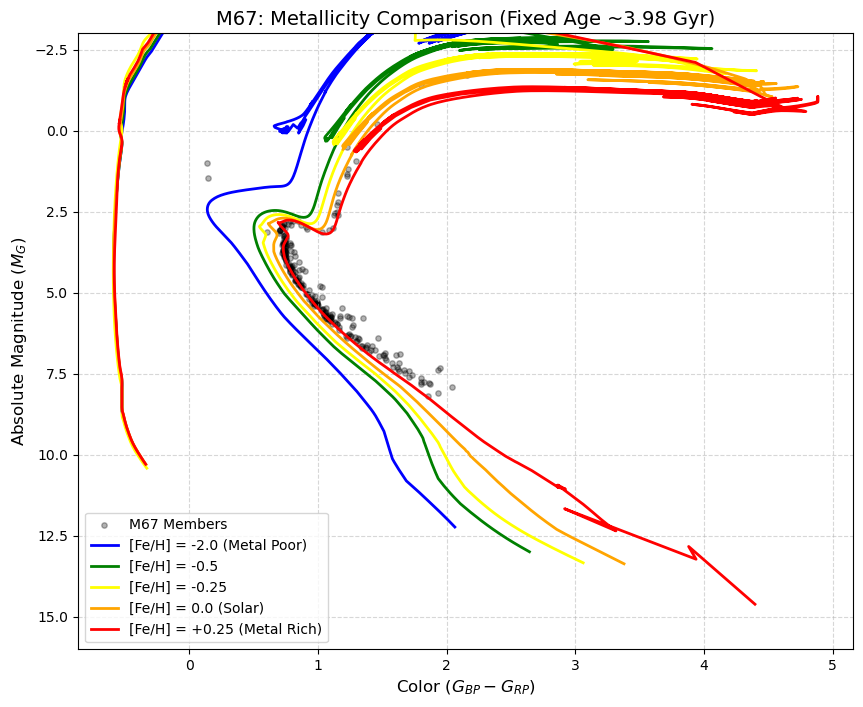

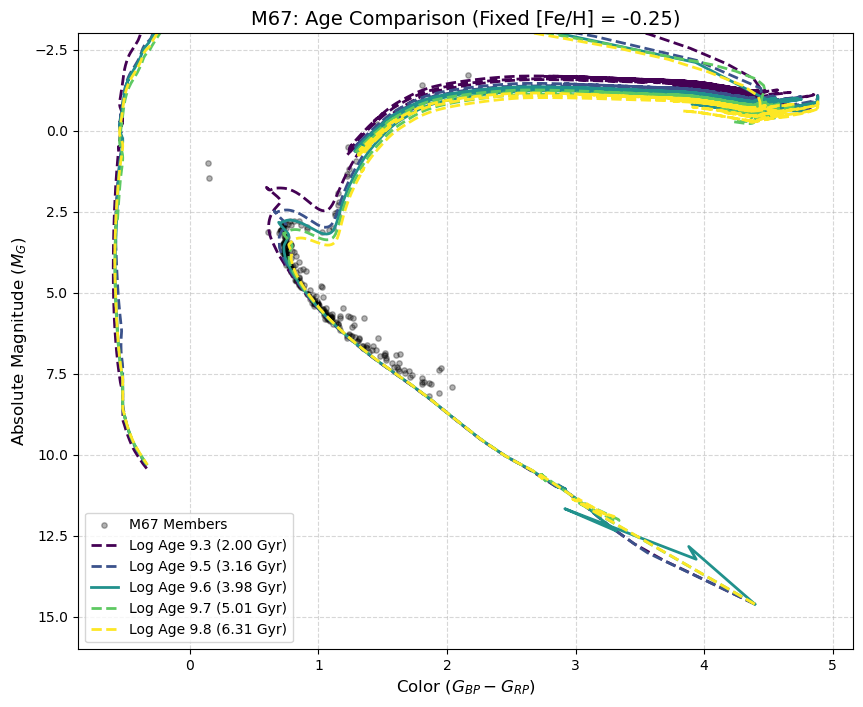

In [29]:
#prepping data
distance_pc = 1000.0 / m67_members['parallax']
abs_mag_g = m67_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = m67_members['bp_rp']

def plot_single_iso(ax, iso_dict, log_age, color_code, label_text, linestyle='-'):
    
    feh_key = list(iso_dict.keys())[0] # Get the metallicity float key 
    
    # Find closest available age in this file
    avail_ages = np.array(list(iso_dict[feh_key].keys()))
    closest_age = avail_ages[np.abs(avail_ages - log_age).argmin()]
    
    data = iso_dict[feh_key][closest_age]
    
    # Try common column names
    try:
        G = data['Gaia_G_EDR3']
        BP = data['Gaia_BP_EDR3']
        RP = data['Gaia_RP_EDR3']
    except KeyError:
        # Fallback if names differ
        cols = data.columns
        G = data[[c for c in cols if 'Gaia_G' in c][0]]
        BP = data[[c for c in cols if 'Gaia_BP' in c][0]]
        RP = data[[c for c in cols if 'Gaia_RP' in c][0]]
        
    ax.plot(BP-RP, G, color=color_code, label=label_text, lw=2, linestyle=linestyle)


# --- Varying Metallicity Plot ---
fixed_log_age = 9.6

fig, ax1 = plt.subplots(figsize=(10, 8))
ax1.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='M67 Members')

# Overplot Isochrones (Different [Fe/H])
plot_single_iso(ax1, iso_metallicity_neg_2,   fixed_log_age, 'blue',   '[Fe/H] = -2.0 (Metal Poor)')
plot_single_iso(ax1, iso_metallicity_neg_pt5, fixed_log_age, 'green',  '[Fe/H] = -0.5')
plot_single_iso(ax1, iso_metallicity_neg_pt25, fixed_log_age, 'yellow', '[Fe/H] = -0.25')
plot_single_iso(ax1, iso_metallicity_0,       fixed_log_age, 'orange', '[Fe/H] = 0.0 (Solar)')
plot_single_iso(ax1, iso_metallicity_pt25,    fixed_log_age, 'red',    '[Fe/H] = +0.25 (Metal Rich)')

# makin it pretty
ax1.invert_yaxis()
ax1.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax1.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax1.set_title(f'M67: Metallicity Comparison (Fixed Age ~3.98 Gyr)', fontsize=14)
ax1.legend(loc='lower left')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylim(16, -3) # Set limits to keep view focused

plt.show()


# --- Varying Age Plot w/ Fixed Metallicity ---
#This one was pretty easy to extrapolate from the NGC CMD. It seemed like a very old/metal poor cluster due to its abundance of red/yellow stars + steep abs. magnitude slope.
base_iso = iso_metallicity_pt25

fig, ax2 = plt.subplots(figsize=(10, 8))

ax2.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='M67 Members')

# Overplot Isochrones (Different Ages)
age_list = [9.3, 9.5, 9.6, 9.7, 9.8,] 
colors = plt.cm.viridis(np.linspace(0, 1, len(age_list))) # gradient colors

for log_age, c in zip(age_list, colors):
    age_gyr = (10**log_age) / 1e9
    label_str = f'Log Age {log_age} ({age_gyr:.2f} Gyr)'
    
    # non dotted line for best fit
    lw = 3 if log_age == 9.6 else 1.5
    ls = '-' if log_age == 9.6 else '--'
    
    plot_single_iso(ax2, base_iso, log_age, c, label_str, linestyle=ls)

# more formatting
ax2.invert_yaxis()
ax2.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax2.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax2.set_title('M67: Age Comparison (Fixed [Fe/H] = -0.25)', fontsize=14)
ax2.legend(loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(16, -3)

plt.show()

### Isochrone/CMD Properties of M67

   * M67 seems to be a medium age cluster that is rich in metal. Graphical analysis allows me to infer that the cluster has a metallicity of about 0.25, and an age of ~3.98 Gyr.

   * The stellar evolution of M67 is different from what I was expecting. I noticed that I captured fewer white dwarves than I did for Hyades. Since M67 is much older than Hyades I was expected it to have many more white dwarves. Instead my CMD shows an abundance of main sequence stars of moderate mass. This aligns with some of my pre-suppositions since M67 is around the same age as our solar system. However, these results raise some doubts about how accurate the inferred ages of the clusters are. 
   

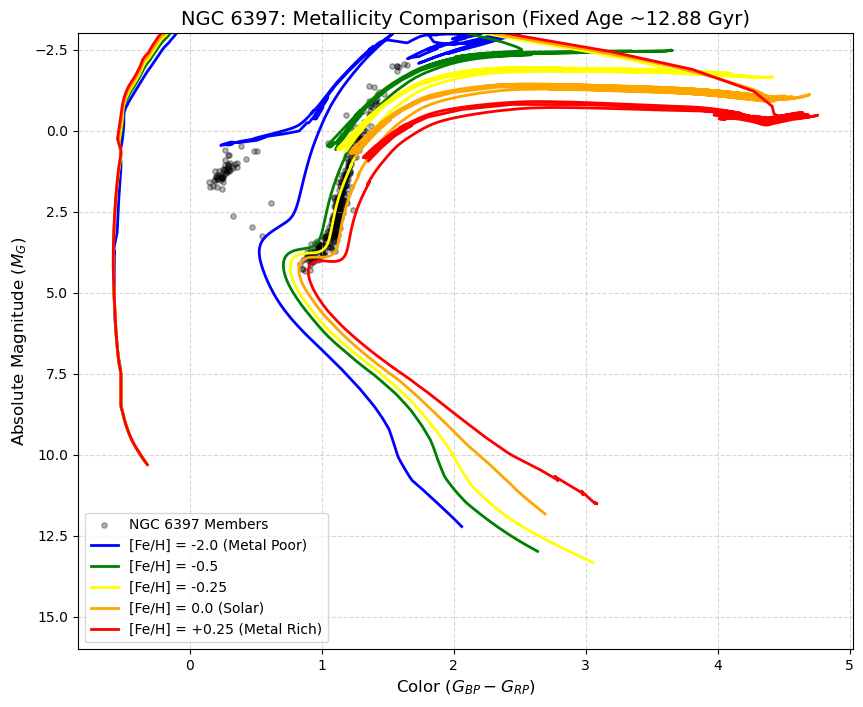

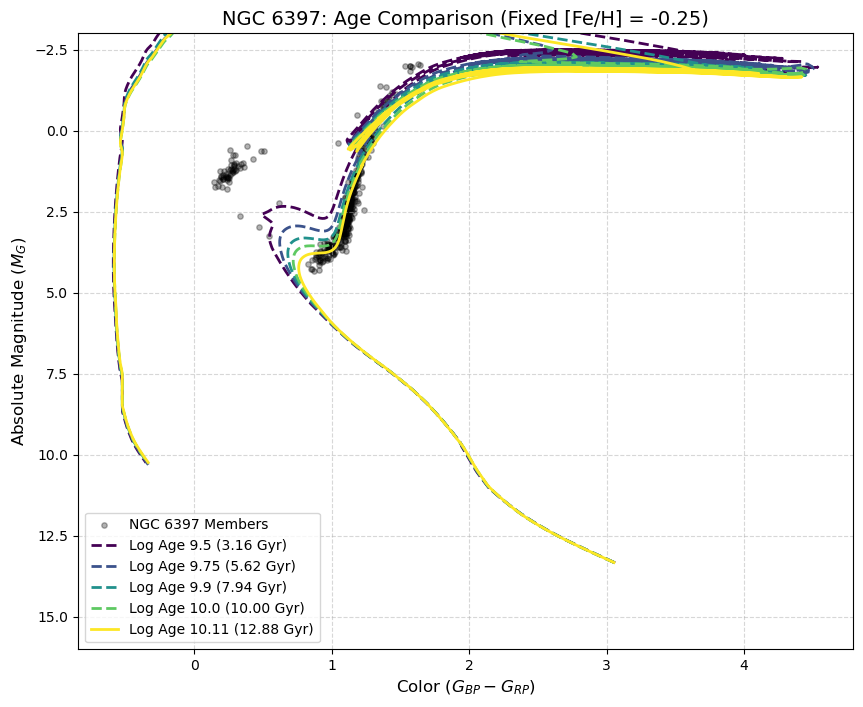

In [30]:
#prepping data
distance_pc = 1000.0 / ngc_members['parallax']
abs_mag_g = ngc_members['phot_g_mean_mag'] - 5 * np.log10(distance_pc) + 5
color = ngc_members['bp_rp']

def plot_single_iso(ax, iso_dict, log_age, color_code, label_text, linestyle='-'):
    
    feh_key = list(iso_dict.keys())[0] # Get the metallicity float key 
    
    # Find closest available age in this file
    avail_ages = np.array(list(iso_dict[feh_key].keys()))
    closest_age = avail_ages[np.abs(avail_ages - log_age).argmin()]
    
    data = iso_dict[feh_key][closest_age]
    
    # Try common column names
    try:
        G = data['Gaia_G_EDR3']
        BP = data['Gaia_BP_EDR3']
        RP = data['Gaia_RP_EDR3']
    except KeyError:
        # Fallback if names differ
        cols = data.columns
        G = data[[c for c in cols if 'Gaia_G' in c][0]]
        BP = data[[c for c in cols if 'Gaia_BP' in c][0]]
        RP = data[[c for c in cols if 'Gaia_RP' in c][0]]
        
    ax.plot(BP-RP, G, color=color_code, label=label_text, lw=2, linestyle=linestyle)


# --- Varying Metallicity Plot ---
fixed_log_age = 10.11

fig, ax1 = plt.subplots(figsize=(10, 8))
ax1.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='NGC 6397 Members')

# Overplot Isochrones (Different [Fe/H])
plot_single_iso(ax1, iso_metallicity_neg_2,   fixed_log_age, 'blue',   '[Fe/H] = -2.0 (Metal Poor)')
plot_single_iso(ax1, iso_metallicity_neg_pt5, fixed_log_age, 'green',  '[Fe/H] = -0.5')
plot_single_iso(ax1, iso_metallicity_neg_pt25, fixed_log_age, 'yellow', '[Fe/H] = -0.25')
plot_single_iso(ax1, iso_metallicity_0,       fixed_log_age, 'orange', '[Fe/H] = 0.0 (Solar)')
plot_single_iso(ax1, iso_metallicity_pt25,    fixed_log_age, 'red',    '[Fe/H] = +0.25 (Metal Rich)')

# makin it pretty
ax1.invert_yaxis()
ax1.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax1.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax1.set_title(f'NGC 6397: Metallicity Comparison (Fixed Age ~12.88 Gyr)', fontsize=14)
ax1.legend(loc='lower left')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_ylim(16, -3) # Set limits to keep view focused

plt.show()


# --- Varying Age Plot w/ Fixed Metallicity ---
#This one was pretty easy to extrapolate from the NGC CMD. It seemed like a very old/metal poor cluster due to its abundance of red/yellow stars + steep abs. magnitude slope.
base_iso = iso_metallicity_neg_pt25

fig, ax2 = plt.subplots(figsize=(10, 8))

ax2.scatter(color, abs_mag_g, s=15, c='black', alpha=0.3, label='NGC 6397 Members')

# Overplot Isochrones (Different Ages)
age_list = [9.5, 9.75, 9.90, 10.0, 10.11,] 
colors = plt.cm.viridis(np.linspace(0, 1, len(age_list))) # gradient colors

for log_age, c in zip(age_list, colors):
    age_gyr = (10**log_age) / 1e9
    label_str = f'Log Age {log_age} ({age_gyr:.2f} Gyr)'
    
    # non dotted line for best fit
    lw = 3 if log_age == 10.11 else 1.5
    ls = '-' if log_age == 10.11 else '--'
    
    plot_single_iso(ax2, base_iso, log_age, c, label_str, linestyle=ls)

# more formatting
ax2.invert_yaxis()
ax2.set_xlabel('Color ($G_{BP} - G_{RP}$)', fontsize=12)
ax2.set_ylabel('Absolute Magnitude ($M_G$)', fontsize=12)
ax2.set_title('NGC 6397: Age Comparison (Fixed [Fe/H] = -0.25)', fontsize=14)
ax2.legend(loc='lower left')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_ylim(16, -3)

plt.show()

### Isochrone/CMD Properties of NGC 6397

   * NGC 6397 seems to be an old cluster with below average metallicity. Graphical analysis allows me to infer that the cluster has a metallicity of about -0.25, and an age of ~12.88 Gyr.

   * In metal poor clusters such as NGC 6397, helium burning stars tend to burn hot and blue, which is consistent with the blue clump that is observed in the upper left of the plot. I also noticed that my main sequence was kind of short and stubby. I am hypothesizing that this is a selection effect due to my parallax filter eliminating the barely luminous lower part of the main sequence. However, the turn off point and the Giants are clearly visible. The red giant branch is also visible at the top of the main sequence, in the steep area that turns off to the right. It seems expected that this cluster would have a high fraction of red giant branch stars since it is a very old cluster.

### Binary Stars

   My RUWE filter did a good job of filtering out most of the binary stars, however you can still see some on the CMDs that I generated. All the stars in the thinner main sequence that seems to run parallel to the isochrones generated, except with slightly higher luminosity  are likely binary stars. This is because Luminosity is an additive quantity, so having two stars in near proximity of each other at the same parallax would result in a large absolute magnitude.

### Deviations from Theoretical Models

   * There is a section in my Hyades isochrone plot that diverges from the stars plotted from 1.5 < G_bp - G_rp < 2.5. It seems to happen around where you would expect the K-type stars to end up. A paper by [Morales et. al. (2008)](https://www.aanda.org/articles/aa/pdf/2008/05/aa8324-07.pdf) mentions that magnetic effects on the stars can drastically alter the temperature of all stars, but K-Type stars are especially susceptible to this and experience large variations.

   * I also noticed that the isochrone fit for Hyades did not extend out toward the white dwarfs located within the cluster. The cluster is certainly old enough for white dwarfs to have formed, so I am uncertain as to why the isochrone data does not extend to where the white dwarfs lie on the CMD.

